In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/Procurement KPI Analysis Dataset.csv")

In [3]:
df.head()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PO_ID             777 non-null    str    
 1   Supplier          777 non-null    str    
 2   Order_Date        777 non-null    str    
 3   Delivery_Date     690 non-null    str    
 4   Item_Category     777 non-null    str    
 5   Order_Status      777 non-null    str    
 6   Quantity          777 non-null    int64  
 7   Unit_Price        777 non-null    float64
 8   Negotiated_Price  777 non-null    float64
 9   Defective_Units   641 non-null    float64
 10  Compliance        777 non-null    str    
dtypes: float64(3), int64(1), str(7)
memory usage: 66.9 KB


In [5]:
df.isnull().sum()

PO_ID                 0
Supplier              0
Order_Date            0
Delivery_Date        87
Item_Category         0
Order_Status          0
Quantity              0
Unit_Price            0
Negotiated_Price      0
Defective_Units     136
Compliance            0
dtype: int64

In [6]:
df[df["Delivery_Date"].isnull()]["Order_Status"].value_counts()

Order_Status
Delivered              68
Cancelled               8
Pending                 6
Partially Delivered     5
Name: count, dtype: int64

In [7]:
df[df["Defective_Units"].isnull()]["Order_Status"].value_counts()

Order_Status
Delivered              102
Partially Delivered     13
Pending                 12
Cancelled                9
Name: count, dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Delivery_Date"] = pd.to_datetime(df["Delivery_Date"])

In [10]:
df["Lead_Time"] = (
    df["Delivery_Date"] - df["Order_Date"]
).dt.days

In [11]:
df["Lead_Time"].describe()

count    690.000000
mean      10.776812
std        5.729210
min       -5.000000
25%        6.000000
50%       11.000000
75%       16.000000
max       20.000000
Name: Lead_Time, dtype: float64

In [12]:
df[df["Lead_Time"] < 0]

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Lead_Time
100,PO-00101,Alpha_Inc,2022-02-27,2022-02-22,Office Supplies,Delivered,211,75.69,65.4,2.0,Yes,-5.0


In [13]:
(df["Lead_Time"] < 0).sum()

np.int64(1)

In [14]:
df = df[df["Lead_Time"] >= 0]

In [15]:
df["Lead_Time"].describe()

count    689.000000
mean      10.799710
std        5.701688
min        1.000000
25%        6.000000
50%       11.000000
75%       16.000000
max       20.000000
Name: Lead_Time, dtype: float64

In [16]:
df.groupby("Supplier")["Lead_Time"].mean().sort_values(ascending=False)

Supplier
Beta_Supplies      11.272727
Epsilon_Group      10.865772
Delta_Logistics    10.854305
Alpha_Inc          10.741379
Gamma_Co           10.192308
Name: Lead_Time, dtype: float64

In [17]:
df.groupby("Item_Category")["Lead_Time"].mean().sort_values(ascending=False)

Item_Category
MRO                11.597315
Electronics        11.021583
Office Supplies    10.510067
Packaging          10.407407
Raw Materials      10.341880
Name: Lead_Time, dtype: float64

In [18]:
df["Compliance"].value_counts()

Compliance
Yes    564
No     125
Name: count, dtype: int64

In [19]:
df["Negotiation_Savings"] = (
    df["Unit_Price"] - df["Negotiated_Price"]
) * df["Quantity"]

In [20]:
df.groupby("Supplier")["Compliance"].value_counts(normalize=True)

Supplier         Compliance
Alpha_Inc        Yes           0.931034
                 No            0.068966
Beta_Supplies    Yes           0.755245
                 No            0.244755
Delta_Logistics  Yes           0.602649
                 No            0.397351
Epsilon_Group    Yes           0.979866
                 No            0.020134
Gamma_Co         Yes           0.853846
                 No            0.146154
Name: proportion, dtype: float64

In [21]:
df.groupby("Supplier")["Defective_Units"].mean().sort_values(ascending=False)

Supplier
Delta_Logistics    157.549550
Beta_Supplies      104.430894
Gamma_Co            56.426087
Epsilon_Group       33.420635
Alpha_Inc           23.967742
Name: Defective_Units, dtype: float64

In [22]:
df.groupby("Supplier")["Negotiation_Savings"].mean().sort_values(ascending=False)

Supplier
Beta_Supplies      5821.979231
Gamma_Co           5151.321692
Epsilon_Group      5077.277785
Alpha_Inc          4784.345862
Delta_Logistics    4618.301987
Name: Negotiation_Savings, dtype: float64

In [23]:
df[df["Order_Status"] == "Cancelled"]["Supplier"].value_counts()

Supplier
Delta_Logistics    16
Alpha_Inc          12
Beta_Supplies      11
Epsilon_Group      10
Gamma_Co            6
Name: count, dtype: int64

In [24]:
supplier_scorecard = df.groupby("Supplier").agg({
    "Lead_Time": "mean",
    "Defective_Units": "mean",
    "Negotiation_Savings": "mean"
})

supplier_scorecard

,Lead_Time,Defective_Units,Negotiation_Savings
Supplier,,,
Alpha_Inc,10.741379,23.967742,4784.345862
Beta_Supplies,11.272727,104.430894,5821.979231
Delta_Logistics,10.854305,157.549550,4618.301987
Epsilon_Group,10.865772,33.420635,5077.277785
Gamma_Co,10.192308,56.426087,5151.321692


In [25]:
compliance_rate = (
    df.groupby("Supplier")["Compliance"]
    .apply(lambda x: (x == "Yes").mean())
)

In [26]:
compliance_rate

Supplier
Alpha_Inc          0.931034
Beta_Supplies      0.755245
Delta_Logistics    0.602649
Epsilon_Group      0.979866
Gamma_Co           0.853846
Name: Compliance, dtype: float64

In [27]:
supplier_scorecard["Compliance_Rate"] = compliance_rate

In [28]:
supplier_scorecard

,Lead_Time,Defective_Units,Negotiation_Savings,Compliance_Rate
Supplier,,,,
Alpha_Inc,10.741379,23.967742,4784.345862,0.931034
Beta_Supplies,11.272727,104.430894,5821.979231,0.755245
Delta_Logistics,10.854305,157.549550,4618.301987,0.602649
Epsilon_Group,10.865772,33.420635,5077.277785,0.979866
Gamma_Co,10.192308,56.426087,5151.321692,0.853846


In [29]:
supplier_scorecard.sort_values(
    by="Compliance_Rate",
    ascending=False
)

,Lead_Time,Defective_Units,Negotiation_Savings,Compliance_Rate
Supplier,,,,
Epsilon_Group,10.865772,33.420635,5077.277785,0.979866
Alpha_Inc,10.741379,23.967742,4784.345862,0.931034
Gamma_Co,10.192308,56.426087,5151.321692,0.853846
Beta_Supplies,11.272727,104.430894,5821.979231,0.755245
Delta_Logistics,10.854305,157.549550,4618.301987,0.602649


In [30]:
supplier_scorecard.sort_values(
    by=["Compliance_Rate", "Defective_Units"],
    ascending=[True, False]
)

,Lead_Time,Defective_Units,Negotiation_Savings,Compliance_Rate
Supplier,,,,
Delta_Logistics,10.854305,157.549550,4618.301987,0.602649
Beta_Supplies,11.272727,104.430894,5821.979231,0.755245
Gamma_Co,10.192308,56.426087,5151.321692,0.853846
Alpha_Inc,10.741379,23.967742,4784.345862,0.931034
Epsilon_Group,10.865772,33.420635,5077.277785,0.979866


In [31]:
supplier_scorecard.to_csv(
    "../data/supplier_scorecard.csv"
)

# Supplier Performance Analysis
## Visualization & KPI Insights

In [33]:
import matplotlib.pyplot as plt

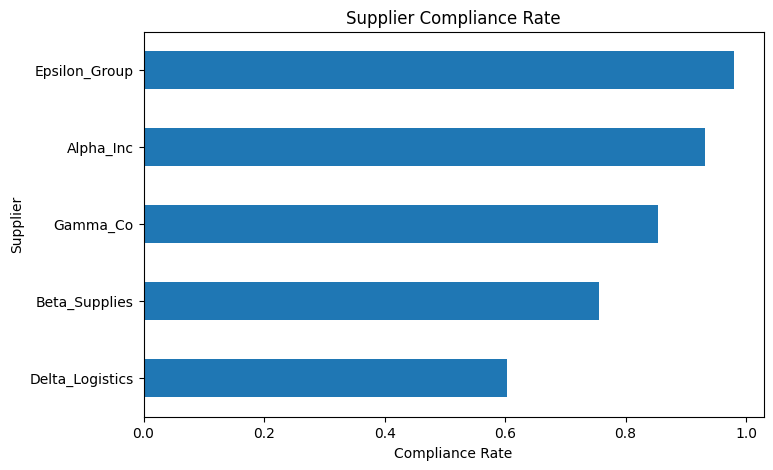

In [34]:
supplier_scorecard["Compliance_Rate"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Supplier Compliance Rate")
plt.xlabel("Compliance Rate")
plt.ylabel("Supplier")

plt.show()

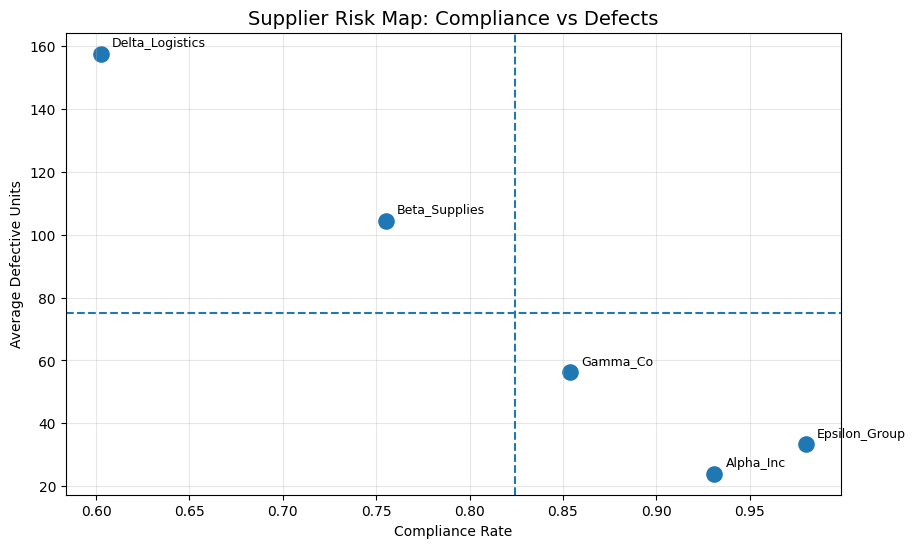

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    supplier_scorecard["Compliance_Rate"],
    supplier_scorecard["Defective_Units"],
    s=120
)

for supplier, row in supplier_scorecard.iterrows():
    ax.annotate(
        supplier,
        (row["Compliance_Rate"], row["Defective_Units"]),
        xytext=(8, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title("Supplier Risk Map: Compliance vs Defects", fontsize=14)
ax.set_xlabel("Compliance Rate")
ax.set_ylabel("Average Defective Units")

ax.axvline(
    supplier_scorecard["Compliance_Rate"].mean(),
    linestyle="--"
)

ax.axhline(
    supplier_scorecard["Defective_Units"].mean(),
    linestyle="--"
)

ax.grid(True, alpha=0.3)

plt.show()

# Executive Summary

## Project Overview

This analysis evaluated supplier performance using procurement KPIs derived from operational purchasing data. The objective was to identify high-performing suppliers, detect operational risks, and support supplier management decisions through KPI-driven analysis and visualization.

The analysis focused on four primary performance dimensions:

- Lead Time
- Compliance Rate
- Defective Units
- Negotiation Savings

---

# Key Findings

## 1. Best Overall Performing Supplier

### Epsilon_Group

Epsilon_Group demonstrated the strongest overall supplier profile based on the combined KPI analysis.

Key strengths:

- Highest compliance rate (~98%)
- Low defective units
- Strong negotiation savings
- Stable operational performance

This supplier appears to combine both process reliability and product quality, making it a strong strategic procurement partner.

---

## 2. Highest Risk Supplier

### Delta_Logistics

Delta_Logistics represents the highest operational risk among all suppliers.

Observed issues:

- Lowest compliance rate (~60%)
- Highest average defective units
- Elevated operational instability

This supplier falls into the high-risk quadrant of the supplier risk map and may negatively impact procurement efficiency, inventory reliability, and downstream operations.

---

## 3. Supplier with Best Compliance Performance

### Epsilon_Group

Epsilon_Group achieved the highest compliance rate in the dataset, indicating strong adherence to procurement standards and operational requirements.

High compliance typically reflects:

- Better delivery discipline
- Stronger process control
- Lower operational friction
- Improved procurement predictability

---

## 4. Supplier with Highest Quality Risk

### Delta_Logistics

Delta_Logistics recorded the highest number of defective units on average, suggesting recurring quality control concerns.

Potential business impacts include:

- Product returns
- Increased inspection costs
- Production delays
- Supplier escalation risks

---

## 5. Relationship Between Compliance and Product Quality

The scatter plot analysis revealed a noticeable negative relationship between:

- Compliance Rate
- Defective Units

Suppliers with higher compliance rates generally exhibited fewer product defects.

This suggests that operational discipline and quality performance are strongly connected within the supplier base.

---

# Business Recommendations

## 1. Strengthen Supplier Governance for High-Risk Vendors

Delta_Logistics and Beta_Supplies should undergo supplier performance review processes.

Recommended actions:

- Conduct supplier audits
- Implement corrective action plans
- Increase quality monitoring frequency
- Establish KPI improvement targets

---

## 2. Expand Strategic Collaboration with Top Suppliers

Epsilon_Group and Alpha_Inc demonstrated consistently strong operational performance.

Recommended actions:

- Increase sourcing allocation
- Develop long-term procurement agreements
- Prioritize strategic partnerships
- Include suppliers in preferred vendor programs

---

## 3. Introduce Supplier Segmentation Framework

Suppliers should be categorized based on KPI performance:

- Strategic Suppliers
- Approved Suppliers
- Watchlist Suppliers
- High-Risk Suppliers

This enables more effective procurement governance and resource allocation.

---

## 4. Monitor KPI Trends Continuously

The current analysis represents a static performance snapshot.

Future improvements should include:

- Monthly KPI tracking
- Trend analysis
- Supplier score evolution
- Automated dashboard reporting

---

# Conclusion

The analysis successfully transformed raw procurement transaction data into actionable supplier intelligence.

By combining KPI engineering, aggregation analysis, and risk visualization, the project identified both strategic suppliers and operational risk areas.

The resulting supplier scorecard provides a foundation for data-driven procurement decision-making and supplier performance management.

In [39]:
from sqlalchemy import create_engine

In [40]:
engine = create_engine("sqlite:///../database/procurement.db")

In [41]:
df.to_sql(
    "procurement_transactions",
    con=engine,
    if_exists="replace",
    index=False
)

689